In [ ]:
import os
import pandas as pd

In [ ]:
IMAGE_BASE_PATH = r"Data\Raw\retinal_images\training_data_set"
TABULAR_DATA_PATH = r"Data\Raw\diabetes_012_health_indicators_BRFSS2015.csv"
OUTPUT_PATH = r"Data\Processed\final_multimodal_data.csv"

In [14]:

def prepare_multimodal_dataset():
    # 1. Thu thập danh sách ảnh
    image_records = []
    for label in ['0', '1', '2', '3', '4']:
        folder_path = os.path.join(IMAGE_BASE_PATH, label)
        if os.path.exists(folder_path):
            files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpeg', '.jpg'))]
            for f in files:
                image_records.append({
                    'image_path': os.path.join(folder_path, f),
                    'label': 0 if label == '0' else 1,
                    'severity_level': int(label)
                })
    
    df_images = pd.DataFrame(image_records)
    if df_images.empty:
        print("Không tìm thấy ảnh.")
        return None

    # 2. Đọc dữ liệu bảng
    df_tab_full = pd.read_csv(TABULAR_DATA_PATH)
    
    # TỰ ĐỘNG TÌM CỘT NHÃN (Diabetes_binary hoặc Diabetes_012 hoặc Outcome)
    possible_target_cols = ['Diabetes_binary', 'Diabetes_012', 'Outcome']
    target_col = next((col for col in possible_target_cols if col in df_tab_full.columns), None)

    if not target_col:
        print(f"Không tìm thấy cột nhãn. Các cột hiện có: {list(df_tab_full.columns[:5])}...")
        return None
    
    print(f"Đã xác định cột nhãn là: '{target_col}'")

    # 3. Ghép cặp (Matching)
    # Tách nhóm để lấy mẫu
    tab_pos = df_tab_full[df_tab_full[target_col] != 0] 
    tab_neg = df_tab_full[df_tab_full[target_col] == 0] 
    
    final_data = []
    for _, img_row in df_images.iterrows():
        # Lấy mẫu ngẫu nhiên từ dữ liệu bảng khớp với nhãn ảnh
        source_df = tab_pos if img_row['label'] == 1 else tab_neg
        sampled_row = source_df.sample(1).iloc[0].to_dict()
            
        sampled_row.update({
            'image_path': img_row['image_path'],
            'severity_level': img_row['severity_level'],
            'Final_Target': img_row['label'] 
        })
        final_data.append(sampled_row)
    
    # 4. Lưu kết quả
    df_final = pd.DataFrame(final_data).sample(frac=1).reset_index(drop=True)
    os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
    df_final.to_csv(OUTPUT_PATH, index=False)
    
    return df_final

# Chạy quy trình
dataset = prepare_multimodal_dataset()
if dataset is not None:
    print(f"Hoàn thành! Dataset: {OUTPUT_PATH}")
    print(f"Tổng số mẫu: {len(dataset)}")

✅ Đã xác định cột nhãn là: 'Diabetes_012'
🚀 Hoàn thành! Dataset đã sẵn sàng tại: C:\Users\ADMIN\OneDrive\Máy tính\HeartDisease\Data\Processed\final_multimodal_data.csv
Tổng số mẫu: 2500


In [15]:
dataset['Diabetes_012'] = dataset['Diabetes_012'].replace({2: 1})
dataset = dataset.rename(columns={'Diabetes_012': 'Diabetes'})

In [16]:
from sklearn.model_selection import train_test_split

# 1. Tách nhãn (Target) và đặc trưng (Features)
y = dataset['Diabetes']
# Loại bỏ các cột không dùng làm đầu vào trực tiếp cho mô hình bảng
X_tabular = dataset.drop(columns=['Diabetes', 'image_path', 'severity_level', 'Final_Target'])

# 2. Chia tập dữ liệu (80% Train, 20% còn lại cho Val & Test)
X_train_tab, X_temp_tab, y_train, y_temp = train_test_split(X_tabular, y, test_size=0.2, random_state=42, stratify=y)

# 3. Chia tiếp 20% temp thành Val (10%) và Test (10%)
X_val_tab, X_test_tab, y_val, y_test = train_test_split(X_temp_tab, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Số lượng mẫu Train: {len(X_train_tab)}")
print(f"Số lượng mẫu Validation: {len(X_val_tab)}")
print(f"Số lượng mẫu Test: {len(X_test_tab)}")

Số lượng mẫu Train: 2000
Số lượng mẫu Validation: 250
Số lượng mẫu Test: 250


In [17]:
from sklearn.preprocessing import StandardScaler
import joblib

# 1. Khởi tạo Scaler
scaler = StandardScaler()

# 2. Fit trên tập Train và Transform cho cả 3 tập
X_train_scaled = scaler.fit_transform(X_train_tab)
X_val_scaled = scaler.transform(X_val_tab)
X_test_scaled = scaler.transform(X_test_tab)

# 3. Lưu Scaler vào thư mục models để dùng cho App sau này
os.makedirs("models", exist_ok=True)
joblib.dump(scaler, "models/scaler.pkl")
# Lưu danh sách tên cột để App biết thứ tự nhập liệu
joblib.dump(X_tabular.columns.tolist(), "models/columns.pkl")

print("Đã chuẩn hóa dữ liệu bảng và lưu Scaler")

✅ Đã chuẩn hóa dữ liệu bảng và lưu Scaler thành công!


In [18]:
# Lấy index của các tập đã chia để lọc đường dẫn ảnh tương ứng
train_idx = X_train_tab.index
val_idx = X_val_tab.index
test_idx = X_test_tab.index

train_img_paths = dataset.loc[train_idx, 'image_path'].values
val_img_paths = dataset.loc[val_idx, 'image_path'].values
test_img_paths = dataset.loc[test_idx, 'image_path'].values

print("Đã đồng bộ hóa đường dẫn ảnh với các tập dữ liệu.")

✅ Đã đồng bộ hóa đường dẫn ảnh với các tập dữ liệu.


In [20]:
import tensorflow as tf
import cv2
import numpy as np

def load_and_preprocess_image(path):

    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = img / 255.0  

def create_multimodal_dataset(img_paths, tab_data, labels, batch_size=32, shuffle=True):

    img_ds = tf.data.Dataset.from_tensor_slices(img_paths)
    img_ds = img_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

    tab_ds = tf.data.Dataset.from_tensor_slices(tab_data)

    label_ds = tf.data.Dataset.from_tensor_slices(labels)

    ds = tf.data.Dataset.zip(((img_ds, tab_ds), label_ds))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(img_paths))
    
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = create_multimodal_dataset(train_img_paths, X_train_scaled, y_train)
val_ds = create_multimodal_dataset(val_img_paths, X_val_scaled, y_val, shuffle=False)
test_ds = create_multimodal_dataset(test_img_paths, X_test_scaled, y_test, shuffle=False)

print(" Data Pipeline đã sẵn sàng nạp dữ liệu song song!")

✅ Data Pipeline đã sẵn sàng nạp dữ liệu song song!


In [21]:
from tensorflow.keras import layers, models

def build_multimodal_model(tabular_shape):
    # --- NHÁNH 1: XỬ LÝ ẢNH (CNN) ---
    base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), 
                                                   include_top=False, weights='imagenet')
    base_model.trainable = False # Đóng băng để tập trung train nhánh bảng trước
    
    image_input = layers.Input(shape=(224, 224, 3), name="image_input")
    x_img = base_model(image_input)
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dense(128, activation='relu')(x_img)
    x_img = layers.Dropout(0.3)(x_img)

    # --- NHÁNH 2: XỬ LÝ DỮ LIỆU BẢNG (Dense) ---
    tabular_input = layers.Input(shape=(tabular_shape,), name="tabular_input")
    x_tab = layers.Dense(64, activation='relu')(tabular_input)
    x_tab = layers.Dense(32, activation='relu')(x_tab)
    x_tab = layers.Dropout(0.2)(x_tab)

    # --- HỢP NHẤT (CONCATENATE) ---
    combined = layers.concatenate([x_img, x_tab])
    
    # Lớp đầu ra cuối cùng
    z = layers.Dense(64, activation='relu')(combined)
    z = layers.Dense(1, activation='sigmoid')(z) # Phân loại nhị phân (0 hoặc 1)

    model = models.Model(inputs=[image_input, tabular_input], outputs=z)
    return model

# Khởi tạo mô hình
input_dim = X_train_scaled.shape[1]
model = build_multimodal_model(input_dim)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC()])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 56s 6us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mobilenetv2_1.00_224          │ (None, 7, 7, 1280)        │       2,257,984 │ image_input[0][0]          │
│ (Functional)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ tabular_input (InputLayer)    │ (None, 21)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d      │ (None, 1280)              │               0 │ mobilenetv2_1.00_224[0][0] │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           1,408 │ tabular_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │         163,968 │ global_average_pooling2d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │           2,080 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 32)                │               0 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 160)               │               0 │ dropout[0][0],             │
│                               │                           │                 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 64)                │          10,304 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 1)                 │              65 │ dense_3[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,435,809 (9.29 MB)

 Trainable params: 177,825 (694.63 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. Định nghĩa nơi lưu mô hình tốt nhất
checkpoint_path = 'models/best_multimodal_model.h5'

# 2. Cấu hình các bộ giám sát (Callbacks)
callbacks = [
    # Tự động dừng nếu Val_Loss không giảm sau 5 lần lặp (Patience)
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    
    # Lưu lại phiên bản có độ chính xác tập Validation cao nhất
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    
    # Tự động giảm tốc độ học (Learning Rate) nếu mô hình bị "khựng" lại
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

# 3. BẮT ĐẦU HUẤN LUYỆN
print("Đang bắt đầu quá trình huấn luyện")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30, # Bạn có thể để 30, EarlyStopping sẽ tự dừng nếu cần
    callbacks=callbacks
)

print(f"\n Model tốt nhất đã được lưu tại: {checkpoint_path}")

🚀 Đang bắt đầu quá trình huấn luyện... Sang hãy kiên nhẫn đợi nhé!
Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8646 - auc: 0.8825 - loss: 0.3159
Epoch 1: val_accuracy improved from None to 0.89200, saving model to models/best_multimodal_model.h5



Epoch 1: finished saving model to models/best_multimodal_model.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.8970 - auc: 0.9430 - loss: 0.2432 - val_accuracy: 0.8920 - val_auc: 0.9683 - val_loss: 0.1825 - learning_rate: 0.0010
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9259 - auc: 0.9734 - loss: 0.1623
Epoch 2: val_accuracy improved from 0.89200 to 0.90000, saving model to models/best_multimodal_model.h5



Epoch 2: finished saving model to models/best_multimodal_model.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9335 - auc: 0.9761 - loss: 0.1559 - val_accuracy: 0.9000 - val_auc: 0.9681 - val_loss: 0.2063 - learning_rate: 0.0010
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9560 - auc: 0.9866 - loss: 0.1173
Epoch 3: val_accuracy improved from 0.90000 to 0.91200, saving model to models/best_multimodal_model.h5



Epoch 3: finished saving model to models/best_multimodal_model.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.9455 - auc: 0.9813 - loss: 0.1386 - val_accuracy: 0.9120 - val_auc: 0.9707 - val_loss: 0.2070 - learning_rate: 0.0010
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9437 - auc: 0.9799 - loss: 0.1500
Epoch 4: val_accuracy did not improve from 0.91200

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
63/63 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.9470 - auc: 0.9836 - loss: 0.1306 - val_accuracy: 0.8960 - val_auc: 0.9693 - val_loss: 0.1933 - learning_rate: 0.0010
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9636 - auc: 0.9920 - loss: 0.0962
Epoch 5: val_accuracy did not improve from 0.91200
63/63 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.9590 - auc: 0.9907 - loss: 0.0985 - val_accuracy: 0.9000 - val_auc: 0.9708 - val_loss: 0.1929 - learning_rate: 2.0000e-04
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s

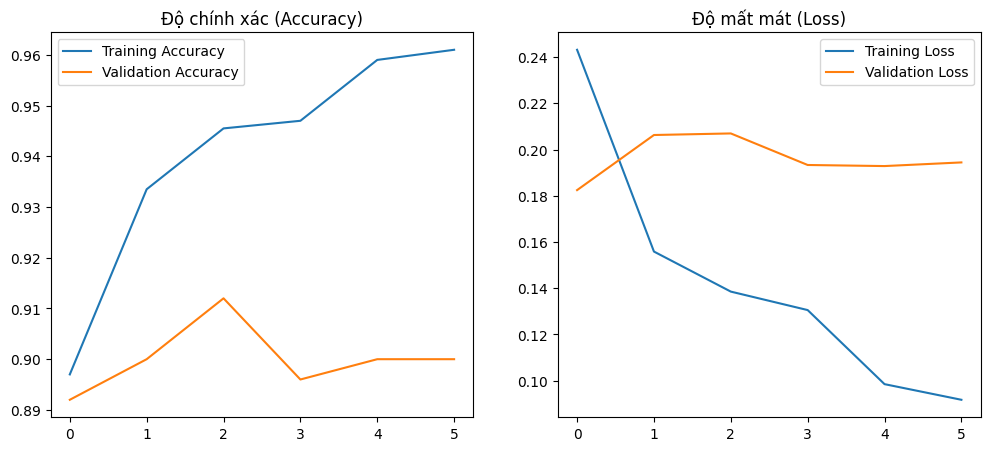

In [23]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Độ chính xác (Accuracy)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Độ mất mát (Loss)')
    plt.legend()
    
    plt.show()

plot_history(history)

🔍 Đang đánh giá trên tập Test...
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step


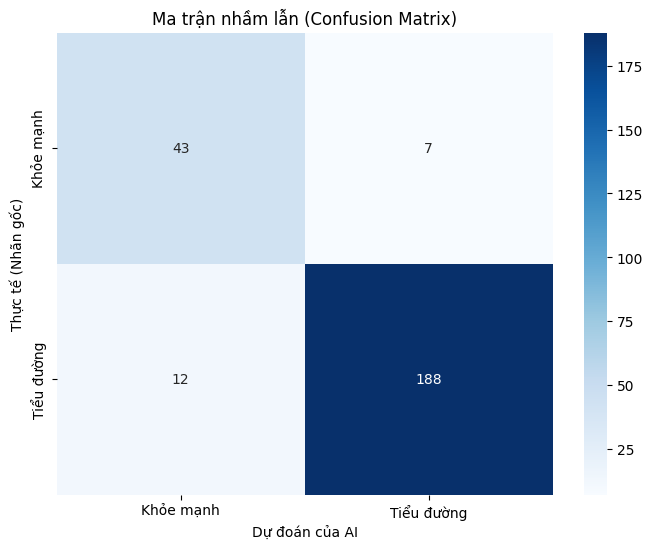


📊 BÁO CÁO CHI TIẾT:
              precision    recall  f1-score   support

   Khỏe mạnh       0.78      0.86      0.82        50
  Tiểu đường       0.96      0.94      0.95       200

    accuracy                           0.92       250
   macro avg       0.87      0.90      0.89       250
weighted avg       0.93      0.92      0.93       250



In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

print("Đang đánh giá trên tập Test...")
y_pred_prob = model.predict(test_ds)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Khỏe mạnh', 'Tiểu đường'], 
            yticklabels=['Khỏe mạnh', 'Tiểu đường'])
plt.xlabel('Dự đoán của AI')
plt.ylabel('Thực tế (Nhãn gốc)')
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.show()

print("\n BÁO CÁO CHI TIẾT:")
print(classification_report(y_test, y_pred, target_names=['Khỏe mạnh', 'Tiểu đường']))

# test

In [25]:
def predict_single_sample(model, img_path, tabular_row):

    img = load_and_preprocess_image(img_path)
    img = tf.expand_dims(img, axis=0) 
    
    tab = tf.expand_dims(tabular_row, axis=0)
    
    prediction = model.predict({"image_input": img, "tabular_input": tab})
    return prediction[0][0]

sample_idx = 0
res = predict_single_sample(model, test_img_paths[sample_idx], X_test_scaled[sample_idx])

print(f"--- KẾT QUẢ TEST THỬ NGHIỆM ---")
print(f"Xác suất mắc bệnh: {res*100:.2f}%")
print(f"Kết luận: {'Dương tính' if res > 0.5 else 'Âm tính'}")
print(f"Thực tế: {'Dương tính' if y_test.iloc[sample_idx] == 1 else 'Âm tính'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
--- KẾT QUẢ TEST THỬ NGHIỆM ---
Xác suất mắc bệnh: 99.77%
Kết luận: Dương tính
Thực tế: Dương tính
